# GC Gold Breakout Backtest

This notebook implements the approved GC Globex breakout backtest as a production-style research workflow. The core engine lives in `gold_breakout_backtest.py`; the notebook keeps the analysis auditable by exposing each major stage, its diagnostics, and its validation outputs in sequence.

## Clarifications and Approved Decisions

- Backtest window is restricted to sessions starting on `2018-08-08 UTC`.
- The missing plan parameters are configurable and default to `fixed_ticks = 100` and `atr_multiplier_tpsl = 2.0`.
- Session boundaries are derived from the observed one-hour maintenance gap in the restricted sample because the UTC open shifts seasonally.
- Trigger evaluation uses adjusted levels; fills, transaction costs, and P&L stay in unadjusted price space.
- Open positions are rolled across dominant-contract changes, with rollover costs recorded separately and included in total trade costs.
- The hourly trailing-stop model is a structural upper bound on live win rate; every win-rate output should be read with that caveat in mind.


## 0. Configuration

All strategy, cost, risk, and file-path parameters live in one block. No downstream cell hardcodes strategy constants.


In [ ]:
import importlib
from pathlib import Path

import gold_breakout_backtest as backtest_module

backtest_module = importlib.reload(backtest_module)
config_frame = backtest_module.config_frame
make_default_config = backtest_module.make_default_config

config = make_default_config(
    csv_path=Path("glbx-mdp3-20100606-20260325.ohlcv-1h.csv"),
    backtest_start_session_date="2018-08-08",
    starting_capital=100_000.0,
    risk_free_rate=0.0,
    min_session_volume=0,
    tp_sl_mode="prior_day_range", # "symmetric_fixed", "atr_based", "prior_day_range"
    fixed_ticks=100,
    atr_multiplier_tpsl=2.0,
    k=0.50,
    atr_period=14,
    atr_multiplier=1.5,
    risk_fraction=0.01,
)

config_frame(config)


,parameter,value
0,csv_path,glbx-mdp3-20100606-20260325.ohlcv-1h.csv
1,backtest_start_session_date,2018-08-08
2,starting_capital,100000.0
3,risk_free_rate,0.0
4,max_ohlc_violations,0
5,min_session_volume,0
6,tp_sl_mode,prior_day_range
7,fixed_ticks,100
8,atr_multiplier_tpsl,2.0
9,k,0.5


## 1. Imports and Environment Setup

Only standard research dependencies are used here: `pandas`, `numpy`, `matplotlib`, and the local backtest module.


In [18]:
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plot_directional_drawdown_curves = backtest_module.plot_directional_drawdown_curves
plot_directional_equity_curves = backtest_module.plot_directional_equity_curves
plot_drawdown_curve = backtest_module.plot_drawdown_curve
plot_equity_curve = backtest_module.plot_equity_curve
plot_exit_reason_breakdown = backtest_module.plot_exit_reason_breakdown
plot_heatmap_grid = backtest_module.plot_heatmap_grid
plot_monthly_returns_heatmap = backtest_module.plot_monthly_returns_heatmap
plot_session_replay = backtest_module.plot_session_replay
plot_sizing_sensitivity_curve = backtest_module.plot_sizing_sensitivity_curve
plot_trade_pnl_distribution = backtest_module.plot_trade_pnl_distribution
plot_trail_sensitivity_curve = backtest_module.plot_trail_sensitivity_curve
prepare_research_data = backtest_module.prepare_research_data
preview_signal_inputs = backtest_module.preview_signal_inputs
run_backtest = backtest_module.run_backtest
run_sensitivity_analysis = backtest_module.run_sensitivity_analysis
run_walk_forward_analysis = backtest_module.run_walk_forward_analysis
summarize_audit = backtest_module.summarize_audit
with_atr_period = backtest_module.with_atr_period

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 120


## 2. Data Ingestion and Validation

The loader enforces the raw CSV schema, filters out non-hourly rows and spreads, resolves duplicates deterministically, and records exclusions plus anomaly flags for review.


In [19]:
prepared = prepare_research_data(config)

display(summarize_audit(prepared.audit))
display(prepared.audit["frames"]["excluded_spreads"].head(10))
display(prepared.audit["frames"]["duplicate_resolution"].head(10))
display(prepared.audit["frames"]["low_volume_sessions_all_outrights"].head(10))


,metric,value
0,raw_rows,1244657
1,excluded_non_rtype_34,0
2,excluded_spread_rows,697405
3,ohlc_violation_count,0
4,duplicate_ts_instrument_rows,0
5,zero_volume_bar_count,0
6,low_liquidity_bar_count,102067
7,session_count_all_outrights,3005


,symbol
694561,GCF0-GCG0
706510,GCF0-GCH0
702146,GCF0-GCJ0
695962,GCF0-GCM0
28134,GCF1-GCG1
43360,GCF1-GCH1
41283,GCF1-GCJ1
783813,GCF1-GCM1
31358,GCF1-GCZ1
111384,GCF2-GCG2


,ts_event,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol,is_spread,selected


,session_id,session_open_ts,session_close_ts,session_bars,session_date,session_open_hour_utc,session_close_hour_utc,previous_session_id,session_total_volume


## 3. Continuous Series Construction

The dominant contract is selected by session-level volume, roll dates are logged, and a backward Panama adjustment is applied while preserving the unadjusted OHLC columns in parallel.


In [20]:
display(prepared.session_table.head(10))
display(prepared.audit["frames"]["roll_log"].head(10))
display(prepared.audit["frames"]["incomplete_or_irregular_sessions"].head(10))


,session_id,session_date,dominant_contract,dominant_volume,previous_dominant_contract,previous_dominant_volume,previous_session_id,roll_flag,session_open_ts,session_close_ts,session_bars,session_open_hour_utc,session_close_hour_utc,session_total_volume,continuous_session_bars,complete_session,first_bar_ts,last_bar_ts,first_close,last_close,first_open,outgoing_last_close,outgoing_last_bar_ts,roll_gap,roll_adjustment,adj_factor,previous_adj_factor,roll_continuity_error
0,1033,2018-08-08 00:00:00+00:00,GCZ8,222297,GCZ8,447203.0,1032.0,False,2018-08-08 22:00:00+00:00,2018-08-09 20:00:00+00:00,23,22,20,224952,23,True,2018-08-08 22:00:00+00:00,2018-08-09 20:00:00+00:00,1221.5,1220.0,1222.0,1221.8,2018-08-08 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
1,1034,2018-08-09 00:00:00+00:00,GCZ8,311942,GCZ8,222297.0,1033.0,False,2018-08-09 22:00:00+00:00,2018-08-10 20:00:00+00:00,23,22,20,315862,23,True,2018-08-09 22:00:00+00:00,2018-08-10 20:00:00+00:00,1219.4,1219.2,1220.0,1220.0,2018-08-09 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
2,1035,2018-08-12 00:00:00+00:00,GCZ8,358849,GCZ8,311942.0,1034.0,False,2018-08-12 22:00:00+00:00,2018-08-13 20:00:00+00:00,23,22,20,367340,23,True,2018-08-12 22:00:00+00:00,2018-08-13 20:00:00+00:00,1220.1,1200.5,1218.4,1219.2,2018-08-10 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
3,1036,2018-08-13 00:00:00+00:00,GCZ8,230127,GCZ8,358849.0,1035.0,False,2018-08-13 22:00:00+00:00,2018-08-14 20:00:00+00:00,23,22,20,233156,23,True,2018-08-13 22:00:00+00:00,2018-08-14 20:00:00+00:00,1201.5,1201.1,1201.1,1200.5,2018-08-13 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
4,1037,2018-08-14 00:00:00+00:00,GCZ8,359134,GCZ8,230127.0,1036.0,False,2018-08-14 22:00:00+00:00,2018-08-15 20:00:00+00:00,23,22,20,366318,23,True,2018-08-14 22:00:00+00:00,2018-08-15 20:00:00+00:00,1201.3,1181.8,1201.5,1201.1,2018-08-14 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
5,1038,2018-08-15 00:00:00+00:00,GCZ8,350694,GCZ8,359134.0,1037.0,False,2018-08-15 22:00:00+00:00,2018-08-16 20:00:00+00:00,23,22,20,356599,23,True,2018-08-15 22:00:00+00:00,2018-08-16 20:00:00+00:00,1182.5,1181.0,1183.0,1181.8,2018-08-15 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
6,1039,2018-08-16 00:00:00+00:00,GCZ8,243884,GCZ8,350694.0,1038.0,False,2018-08-16 22:00:00+00:00,2018-08-17 20:00:00+00:00,23,22,20,247382,23,True,2018-08-16 22:00:00+00:00,2018-08-17 20:00:00+00:00,1181.6,1191.8,1180.7,1181.0,2018-08-16 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
7,1040,2018-08-19 00:00:00+00:00,GCZ8,197220,GCZ8,243884.0,1039.0,False,2018-08-19 22:00:00+00:00,2018-08-20 20:00:00+00:00,23,22,20,200621,23,True,2018-08-19 22:00:00+00:00,2018-08-20 20:00:00+00:00,1190.1,1197.3,1190.4,1191.8,2018-08-17 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
8,1041,2018-08-20 00:00:00+00:00,GCZ8,209607,GCZ8,197220.0,1040.0,False,2018-08-20 22:00:00+00:00,2018-08-21 20:00:00+00:00,23,22,20,213124,23,True,2018-08-20 22:00:00+00:00,2018-08-21 20:00:00+00:00,1197.7,1202.7,1197.3,1197.3,2018-08-20 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0
9,1042,2018-08-21 00:00:00+00:00,GCZ8,222948,GCZ8,209607.0,1041.0,False,2018-08-21 22:00:00+00:00,2018-08-22 20:00:00+00:00,23,22,20,226822,23,True,2018-08-21 22:00:00+00:00,2018-08-22 20:00:00+00:00,1203.1,1202.5,1203.0,1202.7,2018-08-21 20:00:00+00:00,0.0,0.0,636.2,636.2,0.0


,session_id,session_date,previous_dominant_contract,dominant_contract,previous_dominant_volume,dominant_volume,roll_gap,roll_continuity_error
9,9,2010-08-01 00:00:00+00:00,GCQ0,GCZ0,627850.0,409301,-2.2,0.0
29,29,2010-11-28 00:00:00+00:00,GCZ0,GCG1,99270.0,756069,4.3,0.0
39,39,2011-01-30 00:00:00+00:00,GCG1,GCJ1,812854.0,695453,-7.4,0.0
48,48,2011-03-27 00:00:00+00:00,GCJ1,GCM1,691435.0,652318,3.0,0.0
57,57,2011-05-29 00:00:00+00:00,GCM1,GCQ1,816910.0,13153,-2.3,0.0
68,68,2011-07-31 00:00:00+00:00,GCQ1,GCZ1,676827.0,975477,9.1,0.0
87,87,2011-11-27 00:00:00+00:00,GCZ1,GCG2,99485.0,652462,-16.5,0.0
97,97,2012-01-29 00:00:00+00:00,GCG2,GCJ2,840628.0,699961,-2.9,0.0
107,107,2012-04-01 00:00:00+00:00,GCJ2,GCM2,575113.0,543905,-8.0,0.0
116,116,2012-05-28 00:00:00+00:00,GCM2,GCQ2,57988.0,851515,-2.4,0.0


,session_id,session_date,continuous_session_bars,dominant_contract,session_total_volume
0,0,2010-06-06 00:00:00+00:00,120,GCQ0,613041
1,1,2010-06-13 00:00:00+00:00,120,GCQ0,550007
2,2,2010-06-20 00:00:00+00:00,120,GCQ0,641399
3,3,2010-06-27 00:00:00+00:00,119,GCQ0,805409
4,4,2010-07-04 00:00:00+00:00,20,GCQ0,20826
5,5,2010-07-05 00:00:00+00:00,96,GCQ0,524447
6,6,2010-07-11 00:00:00+00:00,120,GCQ0,619630
7,7,2010-07-18 00:00:00+00:00,120,GCQ0,821662
8,8,2010-07-25 00:00:00+00:00,120,GCQ0,1284219
9,9,2010-08-01 00:00:00+00:00,120,GCZ0,459272


## 4. Feature Engineering

This stage creates previous-session breakout levels, previous-session range, true range, and the shifted Wilder ATR used by the strategy.


In [21]:
feature_prepared = with_atr_period(prepared, config.atr_period)

feature_prepared.continuous_data[
    [
        "ts_event",
        "session_date",
        "dominant_contract",
        "adj_open",
        "adj_high",
        "adj_low",
        "adj_close",
        "prev_session_high",
        "prev_session_low",
        "prev_session_range",
        "true_range",
        "atr",
    ]
].head(15)


,ts_event,session_date,dominant_contract,adj_open,adj_high,adj_low,adj_close,prev_session_high,prev_session_low,prev_session_range,true_range,atr
0,2018-08-08 22:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1858.2,1858.3,1857.1,1857.7,1860.5,1849.8,10.7,1.2,2.107505
1,2018-08-08 23:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1857.7,1858.0,1857.2,1857.4,1860.5,1849.8,10.7,0.8,2.042684
2,2018-08-09 00:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1857.3,1858.8,1857.3,1858.5,1860.5,1849.8,10.7,1.5,1.953920
3,2018-08-09 01:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1858.4,1859.0,1856.3,1857.3,1860.5,1849.8,10.7,2.7,1.921498
4,2018-08-09 02:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1857.3,1859.7,1857.2,1858.9,1860.5,1849.8,10.7,2.5,1.977105
5,2018-08-09 03:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1858.8,1859.5,1858.2,1859.0,1860.5,1849.8,10.7,1.3,2.014454
6,2018-08-09 04:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1859.0,1859.5,1858.4,1858.5,1860.5,1849.8,10.7,1.1,1.963422
7,2018-08-09 05:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1858.5,1859.2,1857.7,1859.2,1860.5,1849.8,10.7,1.5,1.901749
8,2018-08-09 06:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1859.1,1861.8,1857.5,1858.0,1860.5,1849.8,10.7,4.3,1.873053
9,2018-08-09 07:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1857.9,1858.1,1854.6,1855.5,1860.5,1849.8,10.7,3.5,2.046406


## 5. Signal Generation

Signals are prepared from session-open inputs only. The actual trigger sequence remains path-dependent and is handled inside the sequential engine, but this preview makes the daily order setup auditable.


In [22]:
signal_preview = preview_signal_inputs(feature_prepared, config, rows=15)
signal_preview


,ts_event,session_date,dominant_contract,prev_session_high,prev_session_low,prev_session_range,atr,sl_distance_price,adj_factor
0,2018-08-08 22:00:00+00:00,2018-08-08 00:00:00+00:00,GCZ8,1860.5,1849.8,10.7,2.107505,5.35,636.2
1,2018-08-09 22:00:00+00:00,2018-08-09 00:00:00+00:00,GCZ8,1861.8,1854.6,7.2,1.893623,3.60,636.2
2,2018-08-12 22:00:00+00:00,2018-08-12 00:00:00+00:00,GCZ8,1861.1,1849.3,11.8,2.337822,5.90,636.2
3,2018-08-13 22:00:00+00:00,2018-08-13 00:00:00+00:00,GCZ8,1857.6,1834.8,22.8,2.727448,11.40,636.2
4,2018-08-14 22:00:00+00:00,2018-08-14 00:00:00+00:00,GCZ8,1842.0,1835.1,6.9,1.954363,3.45,636.2
5,2018-08-15 22:00:00+00:00,2018-08-15 00:00:00+00:00,GCZ8,1838.2,1816.2,22.0,2.887116,11.00,636.2
6,2018-08-16 22:00:00+00:00,2018-08-16 00:00:00+00:00,GCZ8,1825.2,1803.3,21.9,3.337928,10.95,636.2
7,2018-08-19 22:00:00+00:00,2018-08-19 00:00:00+00:00,GCZ8,1828.2,1814.7,13.5,2.750296,6.75,636.2
8,2018-08-20 22:00:00+00:00,2018-08-20 00:00:00+00:00,GCZ8,1833.9,1825.8,8.1,2.202099,4.05,636.2
9,2018-08-21 22:00:00+00:00,2018-08-21 00:00:00+00:00,GCZ8,1840.5,1830.5,10.0,2.389970,5.00,636.2


## 6. Portfolio and Execution Engine

The engine processes sessions chronologically, updates trailing stops bar by bar, supports concurrent long and short positions, rolls open positions across contract changes, and records a full trade lifecycle.


In [23]:
backtest_start = perf_counter()
result = run_backtest(feature_prepared, config)
backtest_elapsed = perf_counter() - backtest_start
print(f"Backtest runtime: {backtest_elapsed:.2f} seconds")

display(result.trade_log.head(10))
display(result.roll_events.head(10))
display(result.order_cancellations.head(10))


Backtest runtime: 7.78 seconds


,trade_id,direction,entry_bar_ts,entry_session_id,entry_session_date,entry_price,contracts,tp_price,initial_sl_price,current_trail_stop,tp_price_adj,initial_sl_price_adj,current_trail_stop_adj,status,exit_price,exit_bar_ts,exit_reason,gross_pnl,transaction_cost,net_pnl,entry_fill_basis,exit_fill_basis,bars_held,roll_count,roll_cost,sizing_equity,risk_per_trade,floor_applied,sl_distance_price,sl_distance_usd,current_contract_at_exit,incremental_gross_pnl,incremental_net_pnl,mfe_price,mae_price,mfe_usd,mae_usd
0,1,short,2018-08-10 05:00:00+00:00,1034,2018-08-09 00:00:00+00:00,1218.3,2,1214.70,1221.90,1221.900000,1850.90,1858.10,1858.100000,closed,1214.700000,2018-08-10 06:00:00+00:00,tp,720.000000,49.48,670.520000,unadjusted_stop_minus_tick_entry,unadjusted_tp_limit_exit,1,0,0.0,100000.000000,1000.000000,False,3.60,360.0,GCZ8,720.000000,670.520000,3.60,0.000000,720.0,0.000000
1,2,short,2018-08-13 07:00:00+00:00,1035,2018-08-12 00:00:00+00:00,1213.0,1,1207.10,1218.90,1211.851787,1843.30,1855.10,1848.051787,closed,1207.100000,2018-08-13 11:00:00+00:00,tp,590.000000,24.74,565.260000,unadjusted_stop_minus_tick_entry,unadjusted_tp_limit_exit,4,0,0.0,100670.520000,1006.705200,False,5.90,590.0,GCZ8,590.000000,565.260000,5.90,0.300000,590.0,30.000000
2,3,short,2018-08-15 00:00:00+00:00,1037,2018-08-14 00:00:00+00:00,1198.8,2,1195.35,1202.25,1199.063463,1831.55,1838.45,1835.263463,closed,1195.350000,2018-08-15 03:00:00+00:00,tp,690.000000,49.48,640.520000,unadjusted_stop_minus_tick_entry,unadjusted_tp_limit_exit,3,0,0.0,101235.780000,1012.357800,False,3.45,345.0,GCZ8,690.000000,640.520000,3.45,1.200000,690.0,240.000000
3,4,short,2018-08-16 00:00:00+00:00,1038,2018-08-15 00:00:00+00:00,1179.9,1,1168.90,1190.90,1175.846917,1805.10,1827.10,1812.046917,closed,1175.946917,2018-08-16 02:00:00+00:00,trail_stop,395.308258,24.74,370.568258,unadjusted_stop_minus_tick_entry,unadjusted_stop_plus_tick_exit,2,0,0.0,101876.300000,1018.763000,True,11.00,1100.0,GCZ8,395.308258,370.568258,9.40,0.000000,940.0,0.000000
4,5,long,2018-08-17 19:00:00+00:00,1039,2018-08-16 00:00:00+00:00,1189.1,1,1200.05,1178.15,1193.148124,1836.25,1814.35,1829.348124,closed,1193.048124,2018-08-20 10:00:00+00:00,trail_stop,394.812377,24.74,370.072377,unadjusted_stop_plus_tick_entry,unadjusted_stop_minus_tick_exit,14,0,0.0,102246.868258,1022.468683,True,10.95,1095.0,GCZ8,394.812377,370.072377,7.40,0.000000,740.0,0.000000
5,6,long,2018-08-20 22:00:00+00:00,1041,2018-08-20 00:00:00+00:00,1197.8,2,1201.85,1193.75,1198.165143,1838.05,1829.95,1834.365143,closed,1201.850000,2018-08-21 04:00:00+00:00,tp,810.000000,49.48,760.520000,unadjusted_stop_plus_tick_entry,unadjusted_tp_limit_exit,6,0,0.0,102616.940635,1026.169406,False,4.05,405.0,GCZ8,810.000000,760.520000,4.05,0.600000,810.0,120.000000
6,7,long,2018-08-22 00:00:00+00:00,1042,2018-08-21 00:00:00+00:00,1204.4,2,1209.40,1199.40,1201.326725,1845.60,1835.60,1837.526725,closed,1201.226725,2018-08-22 06:00:00+00:00,trail_stop,-634.654917,49.48,-684.134917,unadjusted_stop_plus_tick_entry,unadjusted_stop_minus_tick_exit,6,0,0.0,103377.460635,1033.774606,False,5.00,500.0,GCZ8,-634.654917,-684.134917,0.00,3.173275,0.0,634.654917
7,8,short,2018-08-23 01:00:00+00:00,1043,2018-08-22 00:00:00+00:00,1199.1,2,1194.50,1203.70,1199.483541,1830.70,1839.90,1835.683541,closed,1194.500000,2018-08-23 07:00:00+00:00,tp,920.000000,49.48,870.520000,unadjusted_stop_minus_tick_entry,unadjusted_tp_limit_exit,6,0,0.0,102693.325718,1026.933257,False,4.60,460.0,GCZ8,920.000000,870.520000,4.60,0.500000,920.0,100.000000
8,9,short,2018-08-24 00:00:00+00:00,1044,2018-08-23 00:00:00+00:00,1190.1,1,1183.50,1196.70,1193.684880,1819.70,1832.90,1829.884880,closed,1193.784880,2018-08-24 03:00:00+00:00,trail_stop,-368.487980,24.74,-393.227980,unadjusted_stop_minus_tick_entry,unadjusted_stop_plus_tick_exit,3,0,0.0,103563.845718,1035.638457,False,6.60,660.0,GCZ8,-368.487980,-393.227980,0.00,3.684880,0.0,368.487980
9,10,long,2018-08-27 14:00:00+00:00,1045,2018-08-26 00:00:0

,trade_id,roll_session_id,roll_session_date,roll_ts,outgoing_contract,incoming_contract,outgoing_close,incoming_open,contracts,gross_roll_pnl,roll_cost,roll_continuity_error
0,119,1197,2019-03-27 00:00:00+00:00,2019-03-27 22:00:00+00:00,GCJ9,GCM9,1308.5,1315.0,1,350.0,24.74,0.0
1,183,1284,2019-07-29 00:00:00+00:00,2019-07-29 22:00:00+00:00,GCQ9,GCZ9,1426.7,1439.5,1,180.0,24.74,0.0
2,1457,2918,2025-11-24 00:00:00+00:00,2025-11-24 23:00:00+00:00,GCZ5,GCG6,4133.8,4170.3,1,3270.0,24.74,0.0


,session_id,session_date,direction,cancel_ts,stop_level_adj,cancel_reason
0,1034,2018-08-09 00:00:00+00:00,long,2018-08-10 05:00:00+00:00,1861.8,oco_after_short_fill
1,1035,2018-08-12 00:00:00+00:00,long,2018-08-13 07:00:00+00:00,1861.1,oco_after_short_fill
2,1036,2018-08-13 00:00:00+00:00,long,2018-08-14 20:00:00+00:00,1857.6,NaN
3,1036,2018-08-13 00:00:00+00:00,short,2018-08-14 20:00:00+00:00,1834.8,NaN
4,1037,2018-08-14 00:00:00+00:00,long,2018-08-15 00:00:00+00:00,1842.0,oco_after_short_fill
5,1038,2018-08-15 00:00:00+00:00,long,2018-08-16 00:00:00+00:00,1838.2,oco_after_short_fill
6,1039,2018-08-16 00:00:00+00:00,short,2018-08-17 19:00:00+00:00,1803.3,oco_after_long_fill
7,1041,2018-08-20 00:00:00+00:00,short,2018-08-20 22:00:00+00:00,1825.8,oco_after_long_fill
8,1042,2018-08-21 00:00:00+00:00,short,2018-08-22 00:00:00+00:00,1830.5,oco_after_long_fill
9,1043,2018-08-22 00:00:00+00:00,long,2018-08-23 01:00:00+00:00,1844.6,oco_after_short_fill


## 7. Transaction Cost Model

Round-turn costs are applied at the trade level, and approved rollover costs are added for trades that survive dominant-contract changes.


In [24]:
cost_summary = result.performance_summary[
    [
        "gross_total_pnl",
        "net_total_pnl",
        "total_cost_drag",
        "cost_drag_pct_of_gross",
        "sizing_floor_events",
    ]
]

cost_summary.to_frame("value")


,value
gross_total_pnl,96659.321307
net_total_pnl,56110.461307
total_cost_drag,40548.860000
cost_drag_pct_of_gross,41.950284
sizing_floor_events,1236.000000


## 8. Backtest Loop Diagnostics

This view focuses on the chronological engine diagnostics: skipped sessions, concurrency, and margin flags.


In [25]:
display(result.skipped_sessions.head(10))
display(result.margin_flags.head(10))
display(result.diagnostics["session_sizing"].head(10))
display(result.diagnostics["concurrency_log"].head(10))


,session_id,session_date,ts_event,reason
0,1033,2018-08-08 00:00:00+00:00,2018-08-08 22:00:00+00:00,Previous session failed quality filter: incomp...
1,1040,2018-08-19 00:00:00+00:00,2018-08-19 22:00:00+00:00,Open position carried into session; new sessio...
2,1046,2018-08-27 00:00:00+00:00,2018-08-27 22:00:00+00:00,Open position carried into session; new sessio...
3,1051,2018-09-03 00:00:00+00:00,2018-09-03 22:00:00+00:00,Previous session failed quality filter: incomp...
4,1078,2018-10-10 00:00:00+00:00,2018-10-10 22:00:00+00:00,Open position carried into session; new sessio...
5,1106,2018-11-19 00:00:00+00:00,2018-11-19 23:00:00+00:00,Open position carried into session; new sessio...
6,1109,2018-11-22 00:00:00+00:00,2018-11-22 23:00:00+00:00,Previous session failed quality filter: incomp...
7,1110,2018-11-25 00:00:00+00:00,2018-11-25 23:00:00+00:00,Previous session failed quality filter: incomp...
8,1122,2018-12-11 00:00:00+00:00,2018-12-11 23:00:00+00:00,Open position carried into session; new sessio...
9,1131,2018-12-25 00:00:00+00:00,2018-12-25 23:00:00+00:00,Previous session failed quality filter: incomp...


,session_id,session_date,ts_event,flag_type,requested_contracts,allowed_contracts,selected_contracts,allowed_initial_margin,required_initial_margin,selected_initial_margin
0,1238,2019-05-26 00:00:00+00:00,2019-05-26 22:00:00+00:00,margin_cap_applied,4,3,3,50271.971223,60000.0,45000.0


,session_id,session_date,session_open_equity,risk_per_trade,contracts,raw_contracts,floor_contracts,margin_allowed_contracts,floor_applied,margin_cap_applied,max_contracts,contract_cap_applied,sl_distance_price,sl_distance_usd,allowed_initial_margin,required_initial_margin,selected_initial_margin,initial_margin_per_contract
0,1034,2018-08-09 00:00:00+00:00,100000.000000,1000.000000,2,2,2,3,False,False,3,False,3.60,360.0,50000.000000,30000.0,30000.0,15000.0
1,1035,2018-08-12 00:00:00+00:00,100670.520000,1006.705200,1,1,1,3,False,False,3,False,5.90,590.0,50335.260000,15000.0,15000.0,15000.0
2,1036,2018-08-13 00:00:00+00:00,101235.780000,1012.357800,1,0,1,3,True,False,3,False,11.40,1140.0,50617.890000,15000.0,15000.0,15000.0
3,1037,2018-08-14 00:00:00+00:00,101235.780000,1012.357800,2,2,2,3,False,False,3,False,3.45,345.0,50617.890000,30000.0,30000.0,15000.0
4,1038,2018-08-15 00:00:00+00:00,101876.300000,1018.763000,1,0,1,3,True,False,3,False,11.00,1100.0,50938.150000,15000.0,15000.0,15000.0
5,1039,2018-08-16 00:00:00+00:00,102246.868258,1022.468683,1,0,1,3,True,False,3,False,10.95,1095.0,51123.434129,15000.0,15000.0,15000.0
6,1041,2018-08-20 00:00:00+00:00,102616.940635,1026.169406,2,2,2,3,False,False,3,False,4.05,405.0,51308.470318,30000.0,30000.0,15000.0
7,1042,2018-08-21 00:00:00+00:00,103377.460635,1033.774606,2,2,2,3,False,False,3,False,5.00,500.0,51688.730318,30000.0,30000.0,15000.0
8,1043,2018-08-22 00:00:00+00:00,102693.325718,1026.933257,2,2,2,3,False,False,3,False,4.60,460.0,51346.662859,30000.0,30000.0,15000.0
9,1044,2018-08-23 00:00:00+00:00,103563.845718,1035.638457,1,1,1,3,False,False,3,False,6.60,660.0,51781.922859,15000.0,15000.0,15000.0


,ts_event,session_id,open_positions,open_contracts,simultaneous_long_short
0,2018-08-08 22:00:00+00:00,1033,0,0,False
1,2018-08-08 23:00:00+00:00,1033,0,0,False
2,2018-08-09 00:00:00+00:00,1033,0,0,False
3,2018-08-09 01:00:00+00:00,1033,0,0,False
4,2018-08-09 02:00:00+00:00,1033,0,0,False
5,2018-08-09 03:00:00+00:00,1033,0,0,False
6,2018-08-09 04:00:00+00:00,1033,0,0,False
7,2018-08-09 05:00:00+00:00,1033,0,0,False
8,2018-08-09 06:00:00+00:00,1033,0,0,False
9,2018-08-09 07:00:00+00:00,1033,0,0,False


## 9. Performance Analytics

The summary includes headline return, drawdown, risk-adjusted metrics, trade statistics, direction splits, and annual breakdowns.


In [26]:
display(result.performance_summary.to_frame("value"))
display(result.benchmark_summary)
display(result.direction_summary)
display(result.annual_summary)
display(result.exit_breakdown)


,value
terminal_gross_equity,196659.321307
terminal_net_equity,156110.461307
total_return_pct,56.110461
annualized_return_pct,6.015268
max_drawdown_pct,63.652412
max_drawdown_duration_sessions,1690.000000
sharpe_ratio,0.356174
sortino_ratio,0.655802
calmar_ratio,0.094502
total_trades,1521.000000


,series,terminal_equity,total_return_pct,annualized_return_pct,max_drawdown_pct,sharpe_ratio,correlation_to_strategy
0,Strategy Net Equity,156110.461307,56.110461,6.015268,63.652412,0.356174,1.000000
1,GC Price Index,241982.020778,141.982021,12.287852,19.328438,0.852731,0.044934
2,Breakout Session-Close Baseline,271816.100000,171.816100,14.013102,64.471229,0.527205,0.462656


,direction,trades,win_rate_pct,gross_pnl,net_pnl,avg_win_usd,avg_loss_usd,profit_factor,avg_bars_held,avg_mfe_price,avg_mae_price,avg_mfe_usd,avg_mae_usd
0,long,840,41.666667,75084.379912,52694.679912,1060.374138,-649.869936,1.245857,4.429762,8.149940,4.834145,832.250000,494.797377
1,short,681,36.563877,21574.941395,3415.781395,1152.114022,-656.158820,1.079311,4.051395,8.058664,5.610739,824.111601,570.643039


,year,start_equity,end_equity,annual_return_pct,trade_count,win_rate_pct
0,2018,100000.000000,98431.164613,-1.568835,74,33.783784
1,2019,99061.684613,94884.939385,-4.216307,196,41.326531
2,2020,94888.105169,78667.252340,-17.094717,205,38.536585
3,2021,79432.512340,64438.055981,-18.876976,197,34.517766
4,2022,64020.556931,53453.559106,-16.505632,200,39.000000
5,2023,54058.819106,55978.191159,3.550525,194,38.659794
6,2024,55739.406951,49020.361094,-12.054391,200,37.500000
7,2025,49425.919348,90426.852213,82.954315,208,45.192308
8,2026,90594.826287,156110.461307,72.317193,47,51.063830


,exit_reason,count,pct
0,trail_stop,1094,71.926364
1,tp,354,23.274162
2,initial_sl,71,4.667982
3,gap_stop,2,0.131492


## 10. Visualization

Plots focus on analytical clarity: realized equity and drawdown against benchmarks, directional attribution, monthly returns, P&L distributions, and exit composition.


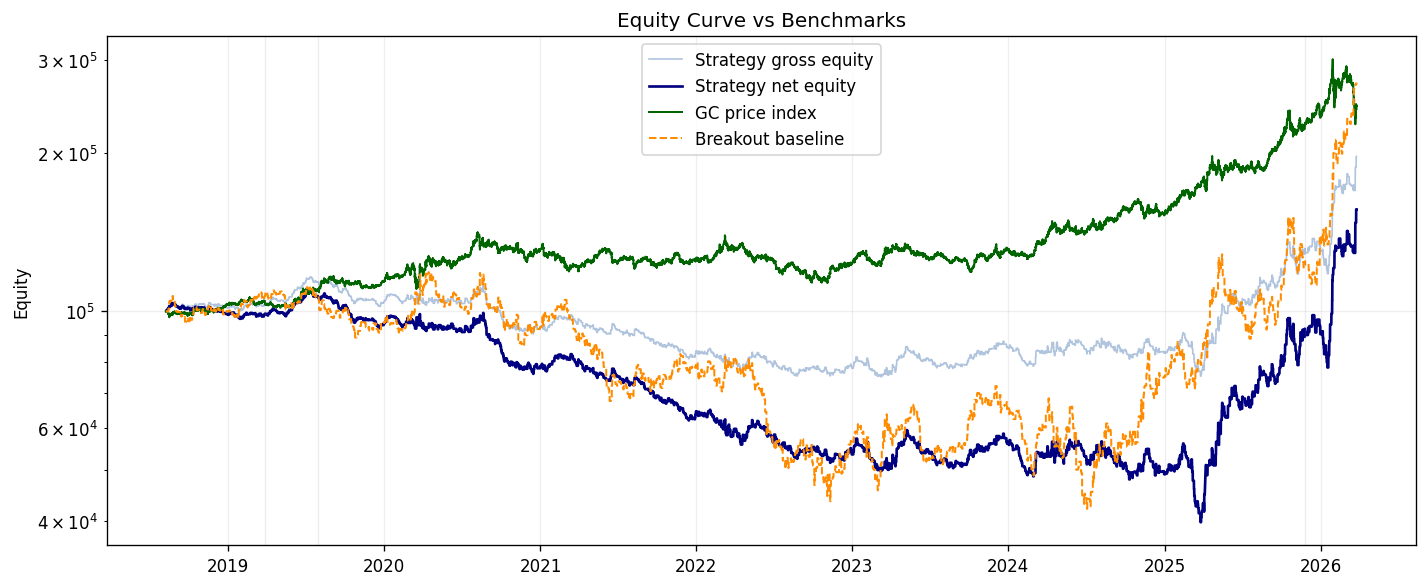

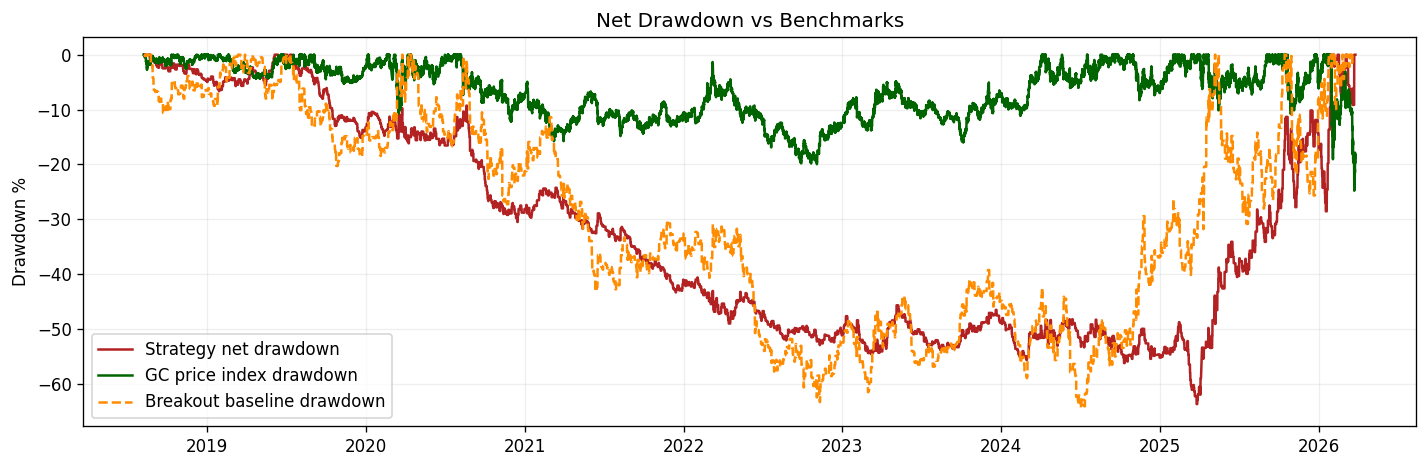

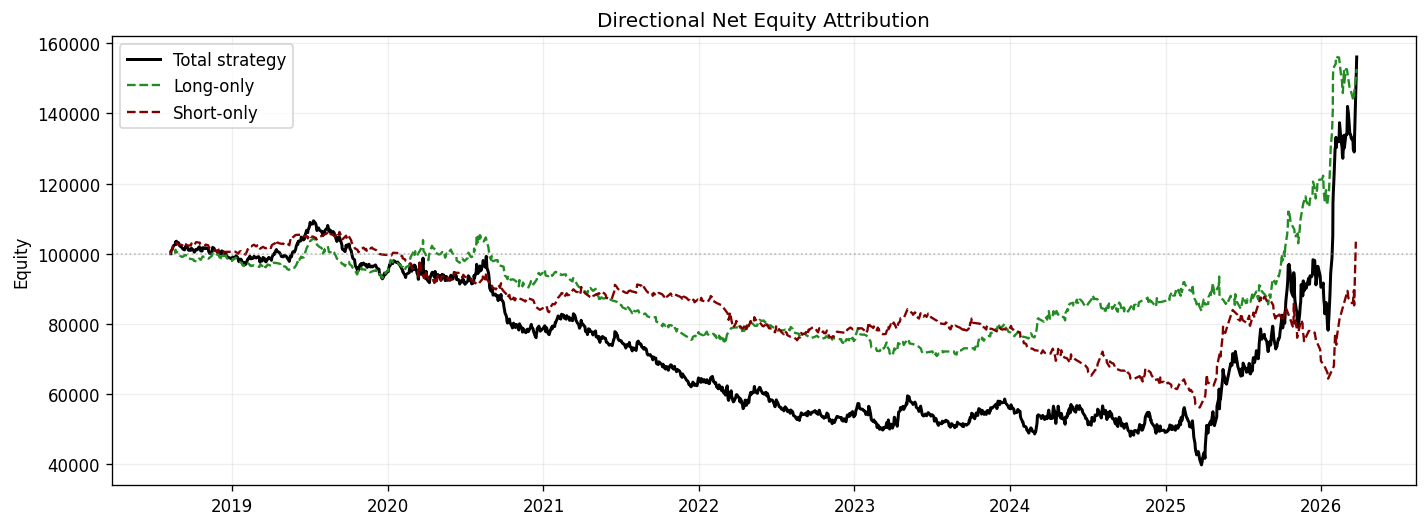

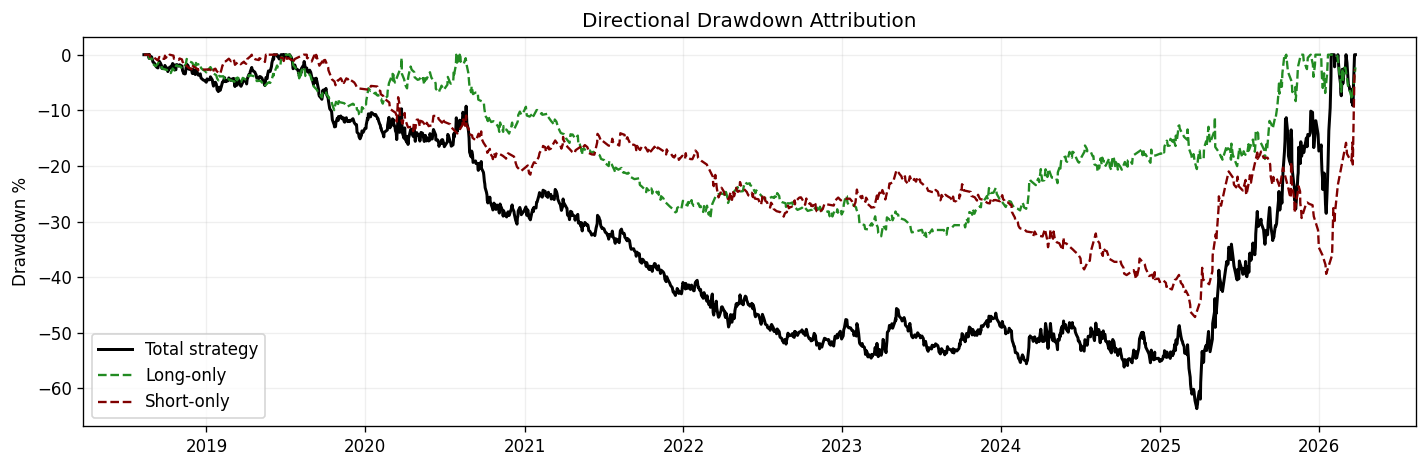

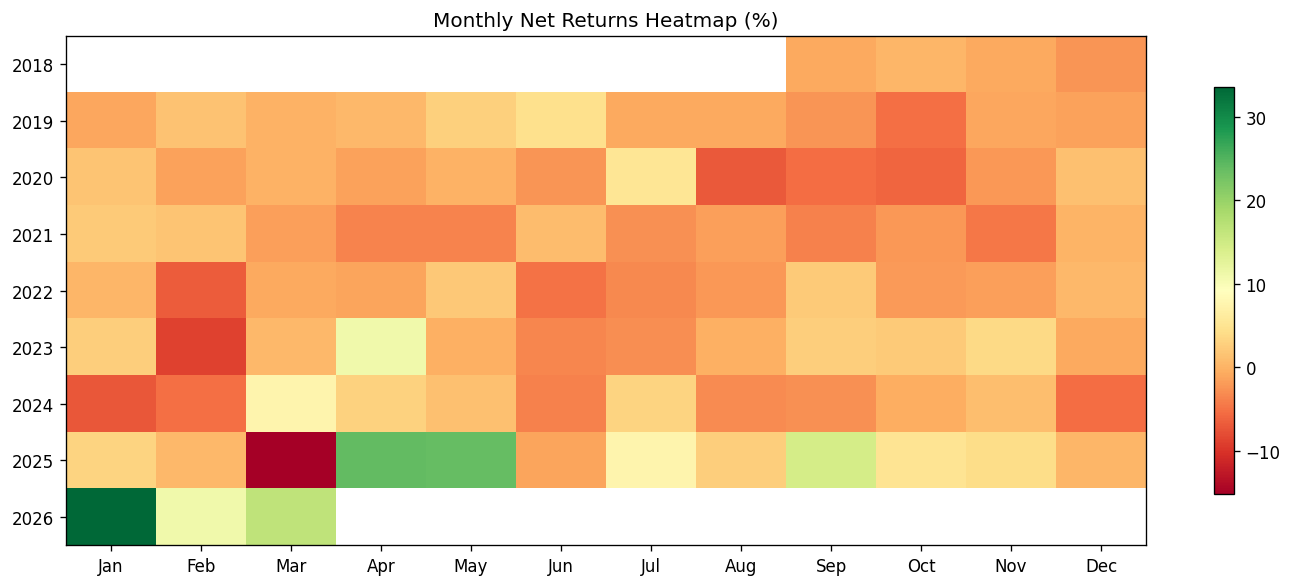

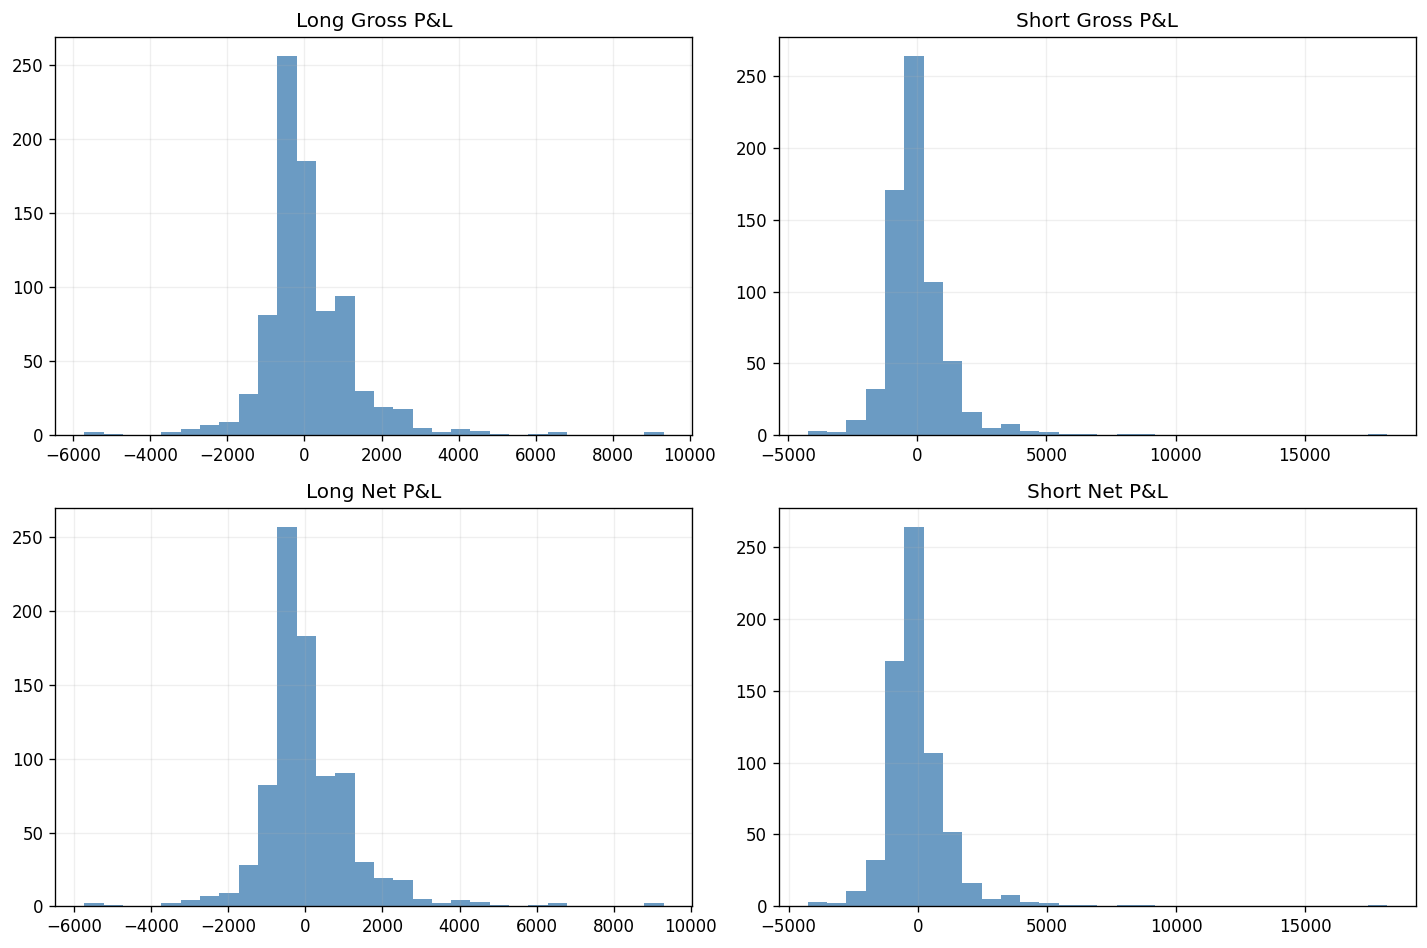

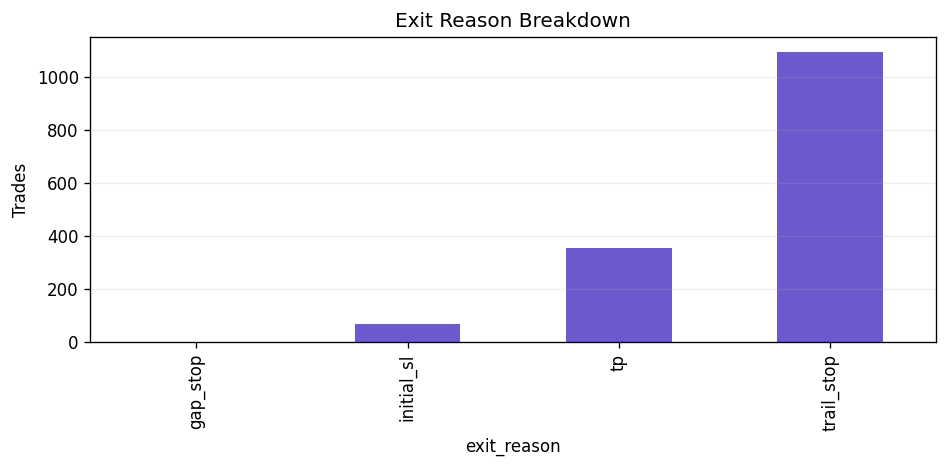

In [27]:
for figure in [
    plot_equity_curve(result),
    plot_drawdown_curve(result),
    plot_directional_equity_curves(result),
    plot_directional_drawdown_curves(result),
    plot_monthly_returns_heatmap(result),
    plot_trade_pnl_distribution(result),
    plot_exit_reason_breakdown(result),
]:
    display(figure)
    plt.close(figure)


## 11. Session Replay

The session replay reconstructs one session from the recorded bars, trade log, cancellations, and skip markers so the breakout logic can be audited visually.


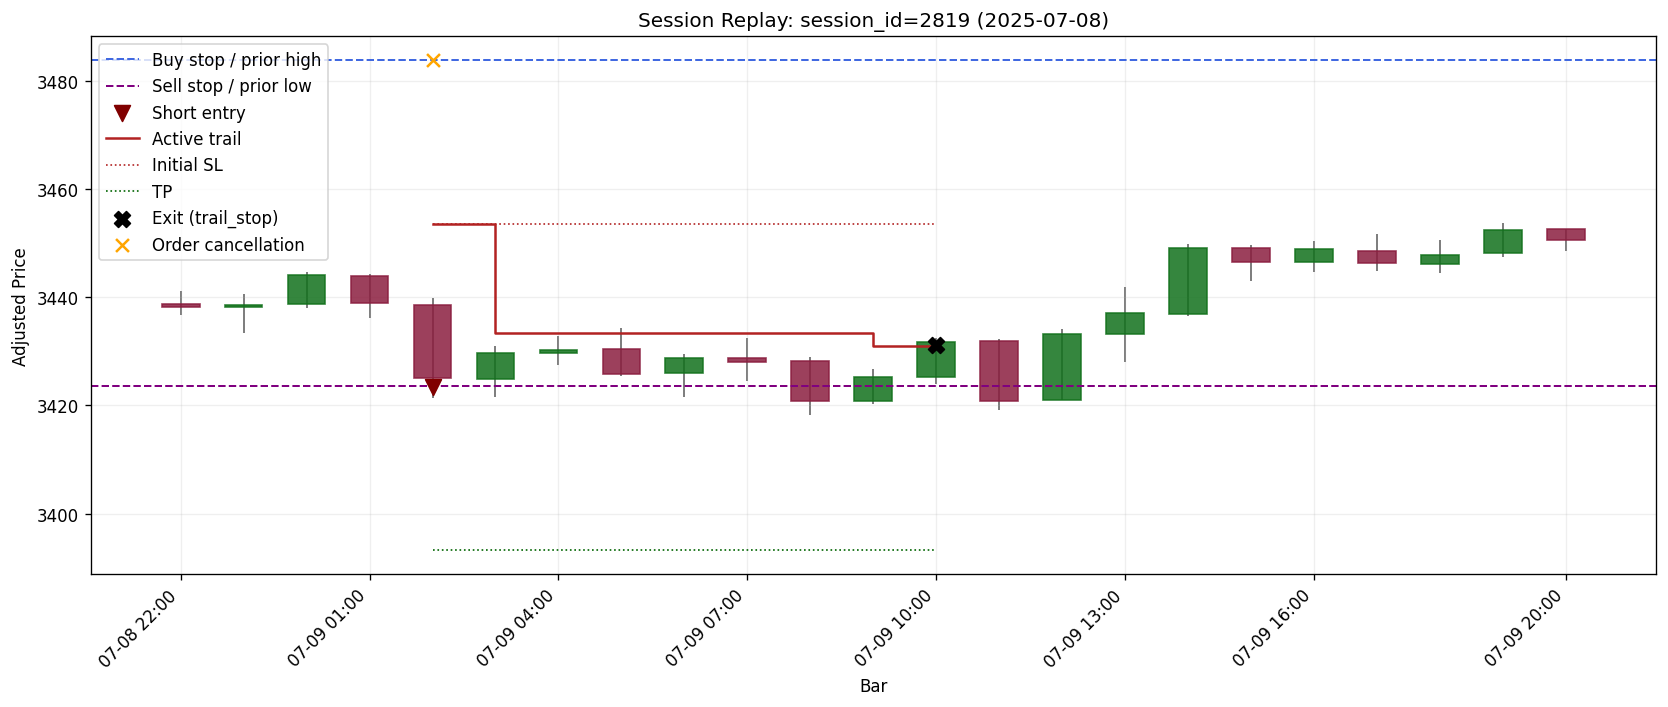

In [33]:
import random

replay_session_id = (
    int(result.trade_log["entry_session_id"].iloc[random.randint(0, len(result.trade_log) - 1)])
    if not result.trade_log.empty
    else int(result.session_table["session_id"].iloc[0])
)

figure = plot_session_replay(result, replay_session_id)
display(figure)
plt.close(figure)


## 12. Sensitivity Analysis

The primary grid reports `atr_multiplier × k` heatmaps by `tp_sl_mode`. For `symmetric_fixed` and `atr_based`, the `k` axis is intentionally repeated because the mode does not consume `k`, but the output shape is kept identical for comparison.

Interpretation note:

- A sharp single-cell optimum is evidence of overfitting risk.
- A broad plateau is evidence of robustness.
- The grid now extends below the prior lower bounds for both `atr_multiplier` and `k`; treat any apparent improvement at those tighter settings as exploratory until it survives walk-forward and slippage realism checks.


Sensitivity runtime: 1341.63 seconds


,atr_period,tp_sl_mode,atr_multiplier,k,win_rate,profit_factor,sharpe_ratio,max_drawdown_pct,terminal_net_equity,total_return_pct,total_trades
0,7,symmetric_fixed,0.25,0.10,56.432567,1.614659,2.450466,13.286450,319567.054804,219.567055,1609.0
1,7,symmetric_fixed,0.25,0.15,56.432567,1.614659,2.450466,13.286450,319567.054804,219.567055,1609.0
2,7,symmetric_fixed,0.25,0.25,56.432567,1.614659,2.450466,13.286450,319567.054804,219.567055,1609.0
3,7,symmetric_fixed,0.25,0.50,56.432567,1.614659,2.450466,13.286450,319567.054804,219.567055,1609.0
4,7,symmetric_fixed,0.25,0.75,56.432567,1.614659,2.450466,13.286450,319567.054804,219.567055,1609.0
5,7,symmetric_fixed,0.25,1.00,56.432567,1.614659,2.450466,13.286450,319567.054804,219.567055,1609.0
6,7,symmetric_fixed,0.50,0.10,48.690773,1.409992,1.360261,8.254519,176525.916504,76.525917,1604.0
7,7,symmetric_fixed,0.50,0.15,48.690773,1.409992,1.360261,8.254519,176525.916504,76.525917,1604.0
8,7,symmetric_fixed,0.50,0.25,48.690773,1.409992,1.360261,8.254519,176525.916504,76.525917,1604.0
9,7,symmetric_fixed,0.50,0.50,48.690773,1.409992,1.360261,8.254519,176525.916504,76.525917,1604.0


,risk_fraction,terminal_net_equity,max_drawdown_pct,sharpe_ratio,total_return_pct,total_trades
0,0.005,152979.597659,65.866075,0.340409,52.979598,1521.0
1,0.010,156110.461307,63.652412,0.356174,56.110461,1521.0
2,0.020,157316.906535,64.911973,0.359464,57.316907,1521.0


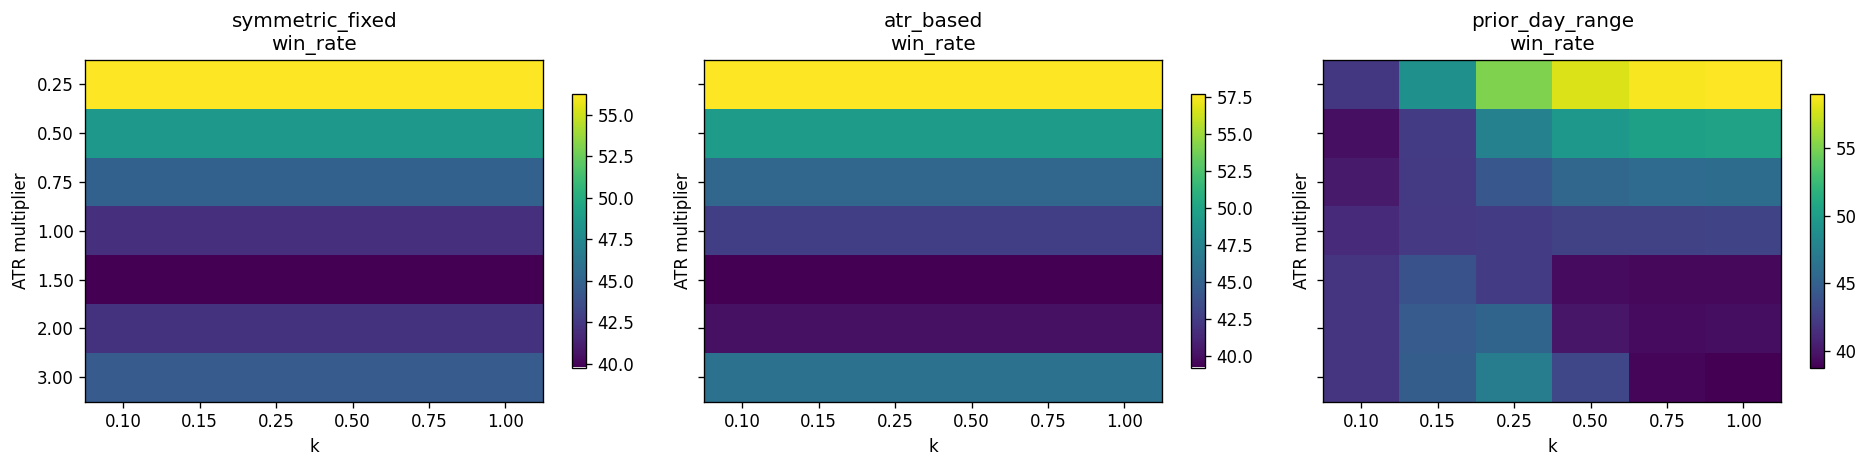

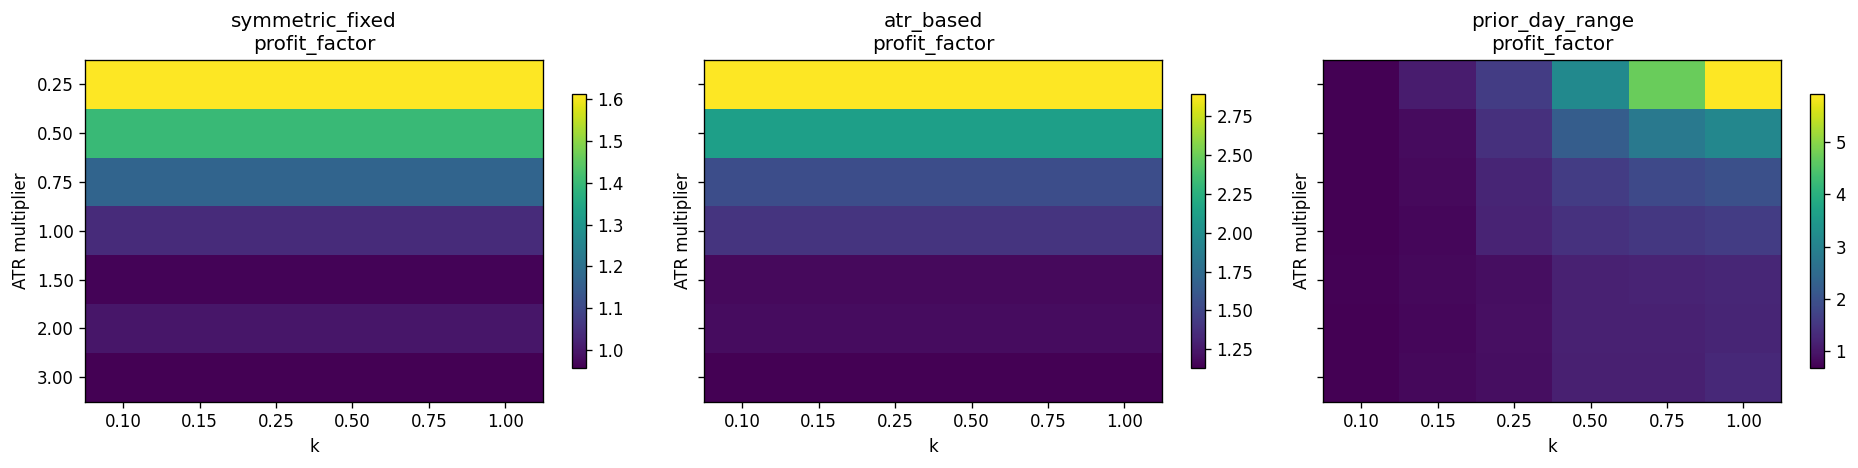

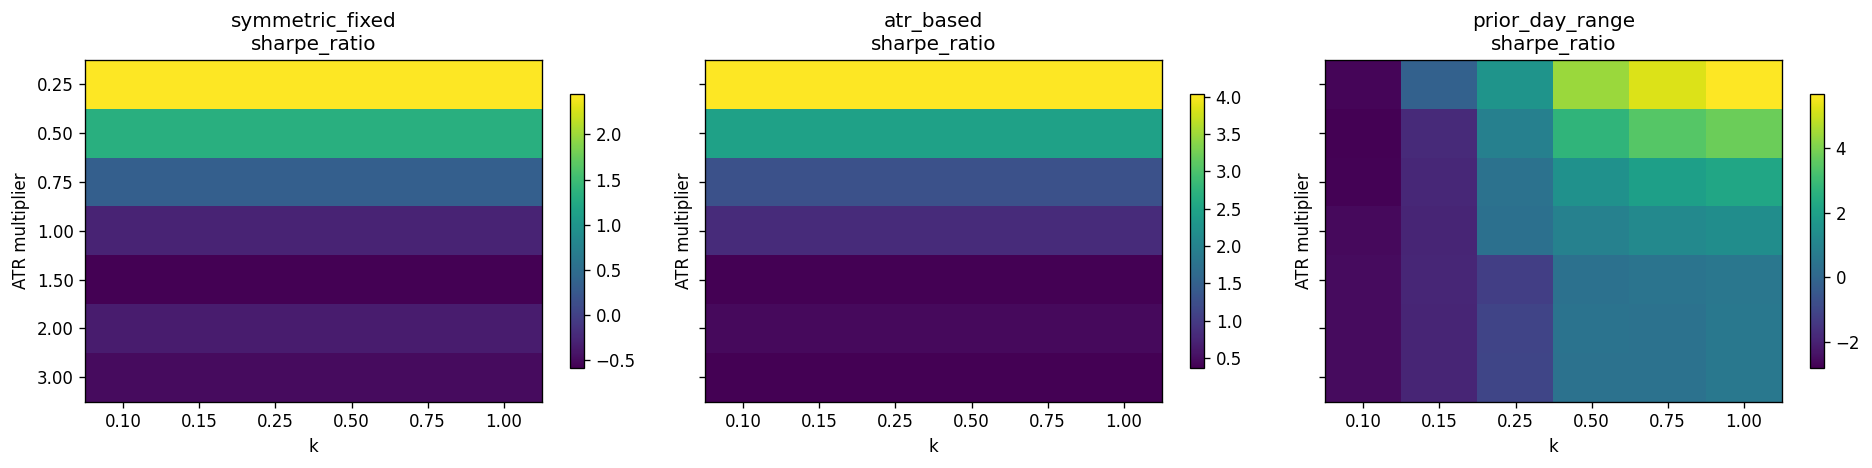

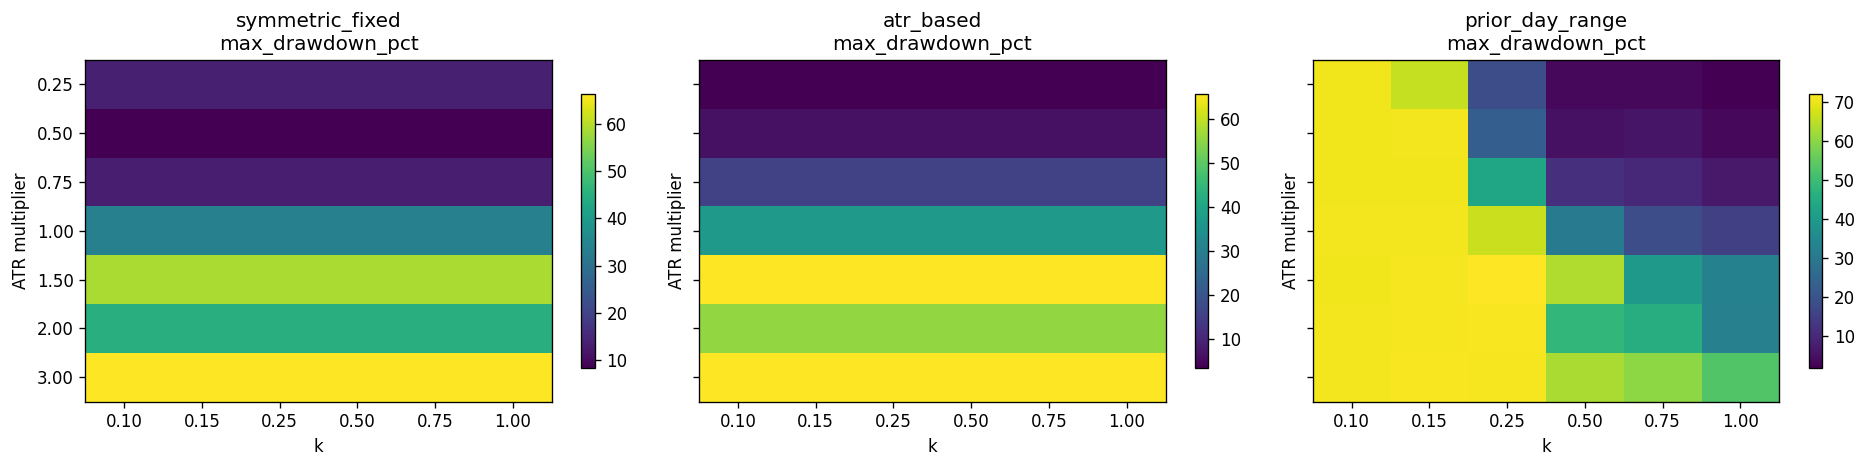

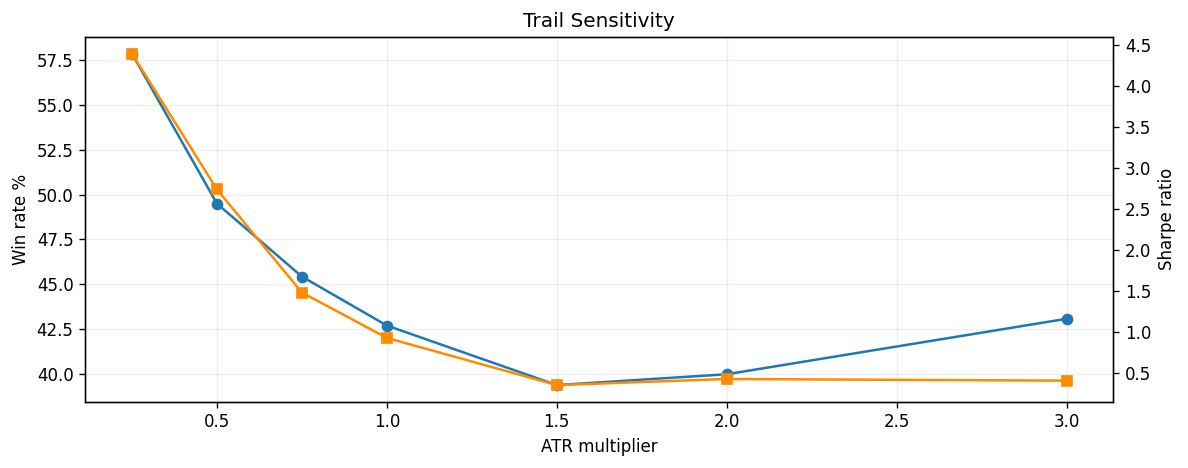

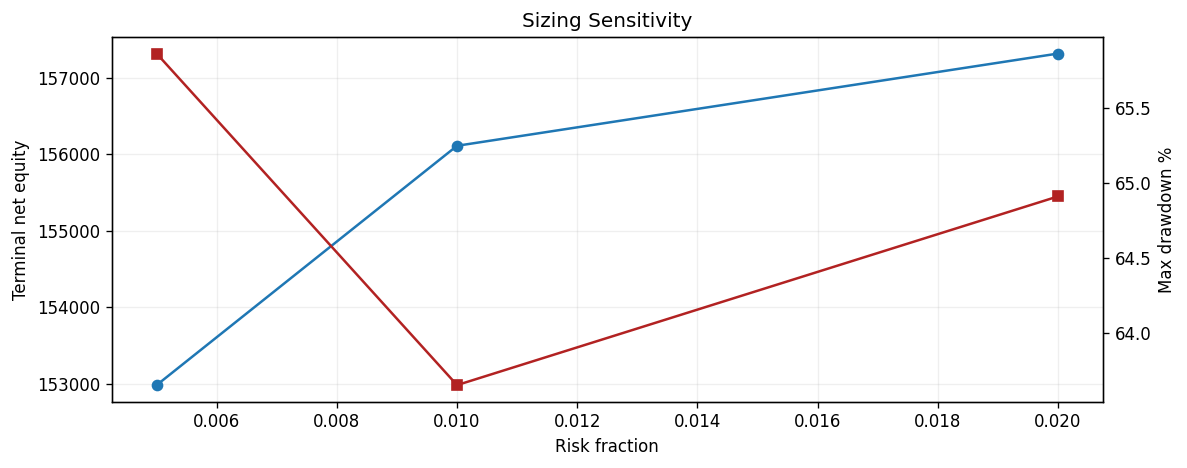

In [29]:
sensitivity_start = perf_counter()
sensitivity = run_sensitivity_analysis(feature_prepared, config)
sensitivity_elapsed = perf_counter() - sensitivity_start
print(f"Sensitivity runtime: {sensitivity_elapsed:.2f} seconds")

primary_grid = sensitivity["primary_grid"]
sizing_grid = sensitivity["sizing_grid"]

display(primary_grid.head(12))
display(sizing_grid)

for metric in ["win_rate", "profit_factor", "sharpe_ratio", "max_drawdown_pct"]:
    figure = plot_heatmap_grid(primary_grid, metric=metric, atr_period=config.atr_period)
    display(figure)
    plt.close(figure)

figure = plot_trail_sensitivity_curve(primary_grid, config)
display(figure)
plt.close(figure)

figure = plot_sizing_sensitivity_curve(sizing_grid)
display(figure)
plt.close(figure)


## 13. Walk-Forward OOS

The walk-forward report uses rolling train/test windows and a deliberately smaller optimization grid than the full sensitivity sweep, so the OOS validation remains computationally practical while still testing parameter stability across time.


Walk-forward runtime: 124.01 seconds


,fold_id,train_start,train_end,test_start,test_end,train_sessions,test_sessions,objective,selected_atr_period,selected_tp_sl_mode,selected_atr_multiplier,selected_k,train_objective_value,train_sharpe_ratio,train_total_return_pct,train_max_drawdown_pct,train_total_trades,oos_sharpe_ratio,oos_total_return_pct,oos_max_drawdown_pct,oos_total_trades,oos_terminal_net_equity
0,1,2018-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,775,259,sharpe_ratio,14,prior_day_range,1.0,0.75,-0.132702,-0.132702,-4.715027,18.588066,613.0,-0.063088,2.701386,5.983396,215.0,102701.385519
1,2,2019-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,2023-08-08 00:00:00+00:00,775,258,sharpe_ratio,14,prior_day_range,1.0,0.75,-0.257164,-0.257164,-9.752676,19.938335,634.0,-0.228719,-2.650869,9.359971,199.0,97349.131474
2,3,2020-08-08 00:00:00+00:00,2023-08-08 00:00:00+00:00,2023-08-08 00:00:00+00:00,2024-08-08 00:00:00+00:00,774,259,sharpe_ratio,14,prior_day_range,1.0,0.75,-0.427706,-0.427706,-14.121277,17.335084,621.0,1.914590,20.847231,6.075060,199.0,120847.230983
3,4,2021-08-08 00:00:00+00:00,2024-08-08 00:00:00+00:00,2024-08-08 00:00:00+00:00,2025-08-08 00:00:00+00:00,776,258,sharpe_ratio,14,prior_day_range,1.0,0.75,0.621481,0.621481,20.897748,9.124767,613.0,2.331622,38.355087,7.620928,207.0,138355.086715


,parameter,value,selected_folds,selected_pct
0,atr_period,14,4,100.0
1,tp_sl_mode,prior_day_range,4,100.0
2,atr_multiplier,1.0,4,100.0
3,k,0.75,4,100.0


,fold_id,train_start,train_end,test_start,test_end,atr_period,tp_sl_mode,atr_multiplier,k,objective,train_objective_value,train_sharpe_ratio,train_total_return_pct,train_max_drawdown_pct,train_total_trades
0,1,2018-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,14,prior_day_range,1.0,0.25,sharpe_ratio,-1.547338,-1.547338,-39.446085,42.634783,620.0
1,1,2018-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,14,prior_day_range,1.0,0.50,sharpe_ratio,-0.563750,-0.563750,-15.737620,21.959897,614.0
2,1,2018-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,14,prior_day_range,1.0,0.75,sharpe_ratio,-0.132702,-0.132702,-4.715027,18.588066,613.0
3,1,2018-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,14,prior_day_range,1.5,0.25,sharpe_ratio,-1.407081,-1.407081,-42.591067,46.411893,605.0
4,1,2018-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,14,prior_day_range,1.5,0.50,sharpe_ratio,-0.838335,-0.838335,-27.600392,33.922742,592.0
5,1,2018-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,14,prior_day_range,1.5,0.75,sharpe_ratio,-0.565017,-0.565017,-20.483425,29.561950,586.0
6,1,2018-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,14,prior_day_range,2.0,0.25,sharpe_ratio,-1.268284,-1.268284,-42.795689,46.036043,598.0
7,1,2018-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,14,prior_day_range,2.0,0.50,sharpe_ratio,-0.574309,-0.574309,-23.226521,29.197575,570.0
8,1,2018-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2021-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,14,prior_day_range,2.0,0.75,sharpe_ratio,-0.382558,-0.382558,-17.076679,28.918534,557.0
9,2,2019-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,2022-08-08 00:00:00+00:00,2023-08-08 00:00:00+00:00,14,prior_day_range,1.0,0.25,sharpe_ratio,-2.113089,-2.113089,-56.225609,57.954149,641.0


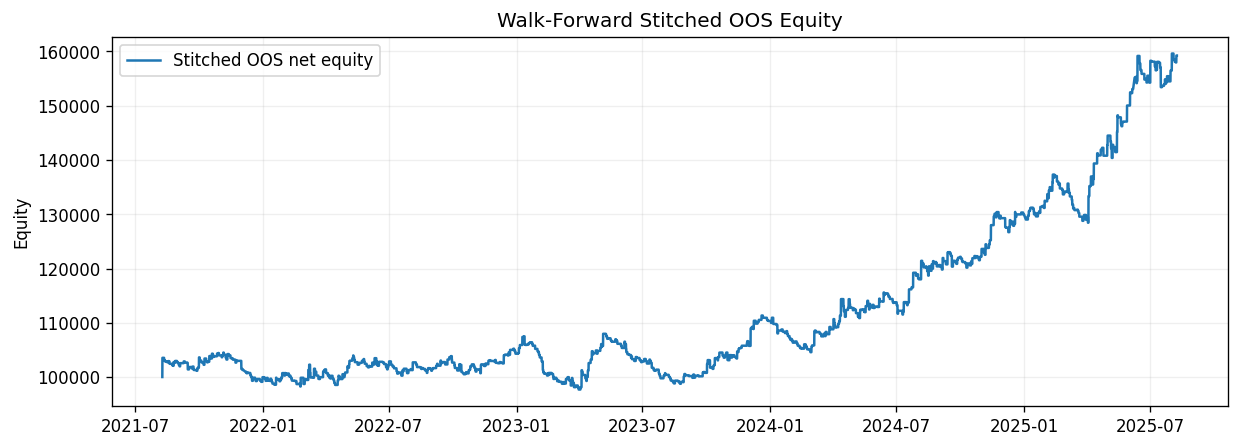

In [34]:
walk_forward_start = perf_counter()
walk_forward = run_walk_forward_analysis(feature_prepared, config)
walk_forward_elapsed = perf_counter() - walk_forward_start
print(f"Walk-forward runtime: {walk_forward_elapsed:.2f} seconds")

display(walk_forward.fold_summary)
display(walk_forward.parameter_stability)
display(walk_forward.optimization_results.head(12))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(walk_forward.oos_equity_curve["ts_event"], walk_forward.oos_equity_curve["net_equity"], label="Stitched OOS net equity")
ax.set_title("Walk-Forward Stitched OOS Equity")
ax.set_ylabel("Equity")
ax.grid(True, alpha=0.2)
ax.legend()
display(fig)
plt.close(fig)


## 14. Validation and Unit Tests

The notebook fails fast if the audited invariants break. These are the core temporal-integrity, cost-accounting, and logging checks required by the plan, adapted where necessary to handle the approved rollover mechanics and the approved unadjusted-fill provenance audit.


In [35]:
display(result.validation_results)
assert (result.validation_results["status"] == "pass").all(), 'One or more validation checks failed.'


,test,status,detail
0,Signal temporal integrity,pass,Session-open breakout levels equal the previou...
1,ATR temporal integrity,pass,Shifted ATR equals the one-bar-lagged Wilder A...
2,ATR warm-up consistency,pass,ATR recomputation for the configured period re...
3,Fill price series provenance,pass,All fills are explicitly tagged as sourced fro...
4,Roll continuity,pass,Adjusted close continuity at each roll is with...
5,Cost accounting,pass,Trade transaction costs equal base round-turn ...
6,Equity monotonicity check,pass,"Entries do not change equity, and each trade u..."
7,Margin cap enforcement,pass,Each trade's initial margin fits within the co...
8,Max contract cap enforcement,pass,Each trade's contracts do not exceed the confi...
9,MAE/MFE diagnostics,pass,Trade-level MAE/MFE diagnostics are populated ...
